# Balanced and Unbalanced Dynamic Geodesics

This notebook generates `fig:dynamic-unbalanced-geodesic`. It compares two lightweight numerical interpolations between two-dimensional Gaussian mixtures with the same total mass but mismatched modal masses.

The balanced row uses entropic Sinkhorn barycenters
\[
\rho_t \approx \arg\min_\rho (1-t)\,\mathcal W^\varepsilon_2(\rho,\alpha)
+t\,\mathcal W^\varepsilon_2(\rho,\beta),
\]
so all mass must be transported. The unbalanced row uses POT's KL-relaxed unbalanced Sinkhorn barycenter, which replaces the hard marginal constraint by a finite penalty. This is not meant as a full dynamic WFR solver; it is a simple and reproducible discretization that makes the same reaction--transport intuition visible: excess mass may fade, and missing mass may be recreated.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from IPython.display import Image, display

from figure_style import (
    BLUE,
    RED,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "dynamic-unbalanced-geodesic"
OUT = figure_dir(NAME)
THUMB = Path("thumbnails") / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)


## Endpoint Gaussian mixtures

Both endpoints contain two vertically separated modes. The source is heavy in the upper-left mode and light in the lower-left mode; the target swaps these proportions on the right. Balanced transport must move the excess upper mass toward the lower target mode, while unbalanced transport can attenuate and recreate part of this modal mismatch.


In [2]:
N = 50
x = np.linspace(-2.20, 2.20, N)
y = np.linspace(-1.55, 1.55, N)
X, Y = np.meshgrid(x, y)
coords = np.column_stack([X.ravel(), Y.ravel()])


def gaussian_2d(mx, my, sx, sy):
    exponent = ((X - mx) / sx) ** 2 + ((Y - my) / sy) ** 2
    return np.exp(-0.5 * exponent) / (2.0 * np.pi * sx * sy)


def normalize_density(Z):
    z = np.asarray(Z, dtype=float).ravel()
    return z / z.sum()


heavy = 0.88
light = 1.0 - heavy
mode_x = 1.22
mode_y = 0.70
sigma_x = 0.20
sigma_y = 0.18

alpha = normalize_density(
    heavy * gaussian_2d(-mode_x, mode_y, sigma_x, sigma_y)
    + light * gaussian_2d(-mode_x, -mode_y, sigma_x, sigma_y)
)
beta = normalize_density(
    light * gaussian_2d(mode_x, mode_y, sigma_x, sigma_y)
    + heavy * gaussian_2d(mode_x, -mode_y, sigma_x, sigma_y)
)
A = np.column_stack([alpha, beta])

M = ot.dist(coords, coords, metric="sqeuclidean")
M /= np.median(M[M > 0])

times = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
REG = 0.005
REG_M = 0.08


## Balanced and unbalanced Sinkhorn barycenters

The endpoints are inserted exactly. Intermediate times are obtained as two-measure barycenters with weights `(1-t, t)`. The unbalanced barycenter is intentionally not renormalized: the lower intensity at intermediate times is part of the mass-variation effect.


In [3]:
balanced = []
unbalanced = []
for t in times:
    if np.isclose(t, 0.0):
        b = alpha.copy()
        u = alpha.copy()
    elif np.isclose(t, 1.0):
        b = beta.copy()
        u = beta.copy()
    else:
        weights = np.array([1.0 - t, t])
        b = ot.bregman.barycenter(
            A,
            M,
            REG,
            weights=weights,
            numItermax=5000,
            stopThr=1e-9,
            warn=False,
        )
        u = ot.unbalanced.barycenter_unbalanced_sinkhorn(
            A,
            M,
            reg=REG,
            reg_m=REG_M,
            weights=weights,
            numItermax=7000,
            stopThr=1e-10,
            log=False,
            verbose=False,
        )
    balanced.append(b.reshape(N, N))
    unbalanced.append(u.reshape(N, N))

balanced = np.stack(balanced)
unbalanced = np.stack(unbalanced)

balanced_masses = balanced.sum(axis=(1, 2))
unbalanced_masses = unbalanced.sum(axis=(1, 2))

# Balanced mass is conserved. The KL-relaxed barycenter keeps positive mass but
# is allowed to vary at intermediate times.
assert np.allclose(balanced_masses, 1.0, atol=3e-5)
assert np.all(unbalanced_masses > 0.65)
assert np.all(unbalanced >= -1e-14)
print("balanced masses:", np.round(balanced_masses, 4))
print("unbalanced masses:", np.round(unbalanced_masses, 4))


balanced masses: [1. 1. 1. 1. 1.]
unbalanced masses: [1.     0.9919 0.8074 0.9919 1.    ]


## Rendering

Each PDF panel contains only the density image, with no embedded title or axis.  The manuscript arranges the row labels and time labels in LaTeX.


In [4]:
PANEL_XLIM = (-1.90, 1.90)
PANEL_YLIM = (-1.15, 1.15)
DENSITY_QUANTILE = 0.990
DENSITY_GAMMA = 0.63


def density_image(Z, t, vmax):
    color = np.array(interp_color(float(t), RED, BLUE))
    level = np.clip(Z / max(vmax, 1e-15), 0.0, 1.0) ** DENSITY_GAMMA
    return 1.0 - level[..., None] * (1.0 - color)


all_panels = np.concatenate(
    [balanced.reshape(len(times), -1), unbalanced.reshape(len(times), -1)], axis=1
)
vmax = np.quantile(all_panels[all_panels > 0], DENSITY_QUANTILE)
extent = [x.min(), x.max(), y.min(), y.max()]

filenames = []
for row_name, row_data in [("balanced", balanced), ("unbalanced", unbalanced)]:
    for t, Z in zip(times, row_data):
        fig, ax = plt.subplots(figsize=(1.55, 0.94))
        ax.imshow(
            density_image(Z, t, vmax),
            origin="lower",
            extent=extent,
            interpolation="bicubic",
        )
        ax.set_xlim(*PANEL_XLIM)
        ax.set_ylim(*PANEL_YLIM)
        ax.set_aspect("equal")
        remove_axes(ax)
        fig.subplots_adjust(0, 0, 1, 1)
        tag = f"{row_name}-t{int(round(100 * t)):03d}.pdf"
        save_pdf(fig, OUT / tag, pad_inches=0.0)
        filenames.append(tag)
        plt.close(fig)

print("Exported", len(filenames), "PDF panels to", OUT)


Exported 10 PDF panels to /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/dynamic-unbalanced-geodesic


## Thumbnail preview

The thumbnail below is only for the notebook gallery.  It uses the same generated arrays as the paper panels.


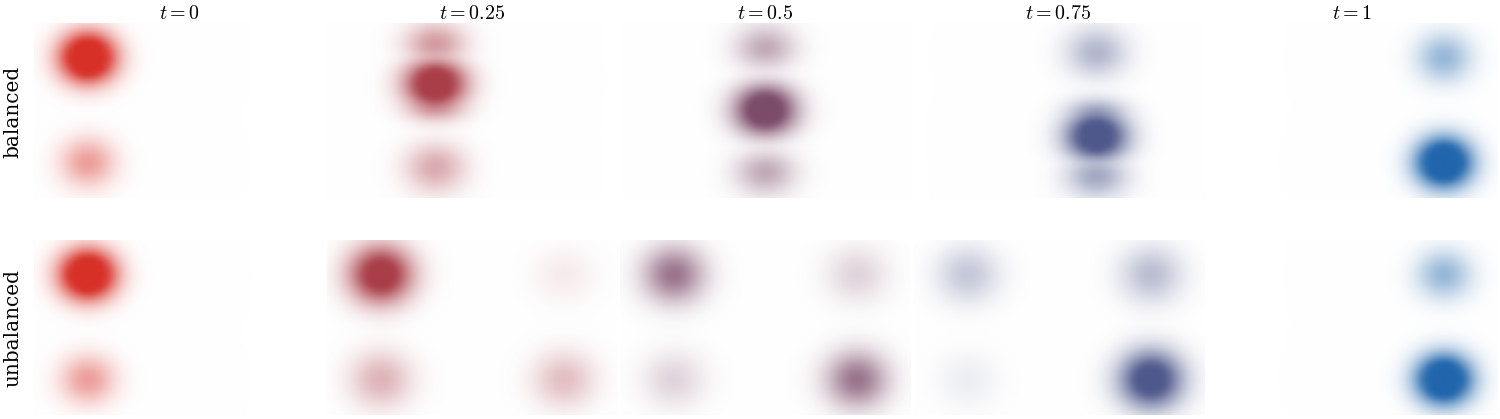

In [5]:
fig, axes = plt.subplots(2, len(times), figsize=(8.6, 2.75))
for r, (row_name, row_data) in enumerate([("balanced", balanced), ("unbalanced", unbalanced)]):
    for c, (t, Z) in enumerate(zip(times, row_data)):
        ax = axes[r, c]
        ax.imshow(
            density_image(Z, t, vmax),
            origin="lower",
            extent=extent,
            interpolation="bicubic",
        )
        ax.set_xlim(*PANEL_XLIM)
        ax.set_ylim(*PANEL_YLIM)
        ax.set_aspect("equal")
        remove_axes(ax)
        if r == 0:
            ax.set_title(rf"$t={t:.2g}$", fontsize=8, pad=2)
        if c == 0:
            ax.text(-2.05, 0.0, row_name, ha="right", va="center", fontsize=8, rotation=90)
fig.subplots_adjust(wspace=0.01, hspace=0.04, left=0.05, right=0.995, top=0.88, bottom=0.02)
fig.savefig(THUMB, dpi=180, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

display(Image(filename=str(THUMB)))
